In [1]:
!curl -LsSf https://astral.sh/uv/install.sh | bash
!uv --version

downloading uv 0.9.7 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
uv 0.9.7


In [2]:
%cd /content/
%rm -rf CS-5137-Deep-Learning

/content


In [3]:
!git clone https://github.com/toan-ly/CS-5137-Deep-Learning
%cd CS-5137-Deep-Learning
!uv sync
%cd homework3

Cloning into 'CS-5137-Deep-Learning'...
remote: Enumerating objects: 1073, done.
remote: Counting objects: 100% (198/198), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 1073 (delta 105), reused 149 (delta 57), pack-reused 875 (from 1)
Receiving objects: 100% (1073/1073), 142.52 MiB | 37.91 MiB/s, done.
Resolving deltas: 100% (288/288), done.
/content/CS-5137-Deep-Learning
Using CPython 3.11.14
Creating virtual environment at: .venv
Resolved 82 packages in 2ms
Prepared 76 packages in 1m 19s
Installed 76 packages in 737ms
 + asttokens==3.0.0
 + comm==0.2.3
 + contourpy==1.3.3
 + cycler==0.12.1
 + debugpy==1.8.17
 + decorator==5.2.1
 + executing==2.2.1
 + filelock==3.19.1
 + fonttools==4.59.2
 + fsspec==2025.9.0
 + ipykernel==6.30.1
 + ipython==9.6.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + jinja2==3.1.6
 + joblib==1.5.2
 + jupyter-client==8.6.3
 + jupyter-core==5.8.1
 + kiwisolver==1.4.9
 + markupsafe==3.0.2
 + matplotlib==3.10.6
 + matplotlib-inline=

In [9]:
!uv run -m src.train \
    --data_root ./data --val_ratio 0.2 \
    --num_workers 2 \
    --cache_rate 1 \
    --epochs 200 --batch_size 4 \
    --loss bce_dice --lr 3e-4 --optimizer adam \
    --use_green_channel \
    --up_mode bilinear \
    --base_channels 64 --depth 2 \
    --early_stopping \
    --early_stopping_patience 20 \
    --save_dir checkpoints --save_plots_path results/predictions \
    --device cuda

Loading dataset: 100% 64/64 [00:00<00:00, 65.82it/s]
Loading dataset: 100% 16/16 [00:00<00:00, 83.27it/s]
Epoch 10/200 - Train Loss: 1.9668, Train Dice: 0.7610, Train IoU: 0.6194 | Val Loss: 0.2350, Val Dice: 0.7430, Val IoU: 0.5940
Epoch 20/200 - Train Loss: 1.7648, Train Dice: 0.7860, Train IoU: 0.6505 | Val Loss: 0.2124, Val Dice: 0.7825, Val IoU: 0.6447
Epoch 30/200 - Train Loss: 1.7698, Train Dice: 0.7842, Train IoU: 0.6483 | Val Loss: 0.2127, Val Dice: 0.7835, Val IoU: 0.6461
Epoch 40/200 - Train Loss: 1.7364, Train Dice: 0.7899, Train IoU: 0.6554 | Val Loss: 0.2122, Val Dice: 0.7836, Val IoU: 0.6463
Epoch 50/200 - Train Loss: 1.7320, Train Dice: 0.7902, Train IoU: 0.6564 | Val Loss: 0.2127, Val Dice: 0.7829, Val IoU: 0.6453
Epoch 60/200 - Train Loss: 1.7533, Train Dice: 0.7865, Train IoU: 0.6513 | Val Loss: 0.2116, Val Dice: 0.7846, Val IoU: 0.6476
Epoch 70/200 - Train Loss: 1.7363, Train Dice: 0.7901, Train IoU: 0.6556 | Val Loss: 0.2119, Val Dice: 0.7838, Val IoU: 0.6465
Epoch

In [5]:
# %mv results/predictions results/predictions1
# %mv checkpoints checkpoints1
# %mkdir results/predictions
# %mkdir checkpoints

# !uv run -m src.train \
#     --data_root ./data --val_ratio 0.2 \
#     --num_workers 2 \
#     --cache_rate 1 \
#     --epochs 200 --batch_size 16 \
#     --loss bce_dice --lr 3e-4 --optimizer adamw \
#     --up_mode bilinear \
#     --base_channels 64 --depth 4 \
#     --early_stopping \
#     --early_stopping_patience 20 \
#     --save_dir checkpoints --save_plots_path results/predictions \
#     --device cuda

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
history_df = pd.read_csv('checkpoints/training_history.csv')
history_df.head()

,Unnamed: 0,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,epoch
0,0,4.299729,0.503597,0.352158,0.599191,0.117169,0.066327,1
1,1,3.240476,0.653127,0.497075,0.429723,0.425536,0.278616,2
2,2,2.967915,0.668068,0.513048,0.390907,0.607121,0.438645,3
3,3,2.692561,0.702314,0.550054,0.340926,0.692572,0.533355,4
4,4,2.510867,0.719059,0.568473,0.327112,0.697736,0.539144,5


In [ ]:
# history_df2 = pd.read_csv('checkpoints1/training_history.csv')
# history_df2.head()

In [11]:
def plot_loss(loss_df, save_dir):
    """
    Plots training and validation loss, accuracy, and F1 score
    over epochs for different models and learning rates.
    """

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].plot(loss_df['epoch'], loss_df['train_loss'], label='train_loss')
    axs[0].plot(loss_df['epoch'], loss_df['val_loss'], label='val_loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training and Validation Loss')
    axs[0].legend()

    axs[1].plot(loss_df['epoch'], loss_df['train_dice'], label='train_dice')
    axs[1].plot(loss_df['epoch'], loss_df['val_dice'], label='val_dice')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Dice')
    axs[1].set_title('Training and Validation Dice')
    axs[1].legend()

    axs[2].plot(loss_df['epoch'], loss_df['train_iou'], label='train_iou')
    axs[2].plot(loss_df['epoch'], loss_df['val_iou'], label='val_iou')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('IoU')
    axs[2].set_title('Training and Validation IoU')
    axs[2].legend()

    plt.tight_layout()
    plt.show()


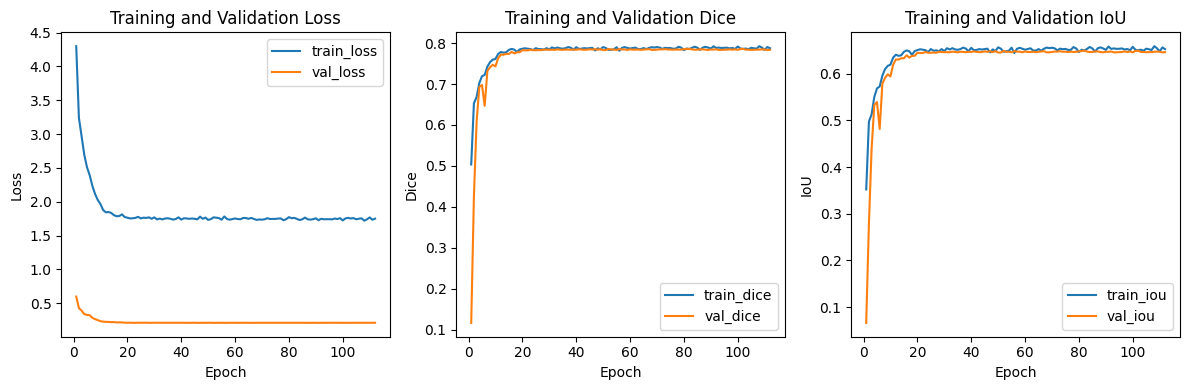

In [12]:
plot_loss(history_df, 'checkpoints')

In [ ]:
# plot_loss(history_df2, 'checkpoints1')